# Week 6: Propaganda Detection

### Introduction

This week we will be looking at the propaganda detection task (Da San Martino 2019) and developing a baseline model for technique **classification**.

We will be working with an adapted version of the dataset from the paper.  In particular, I have
* reduced the number of propaganda techniques
* randomly sampled sentences labelled with a particular technique
* randomly sampled sentences (from the same original articles) which do not contain propaganda
* reformatted the data so that the snippets can be "read" in the context of the sentence by inserting \<BOS\> and \<EOS\> tags.

Let's load it up in a pandas dataframe so that we can look at some examples to illustrate that last point.

In [92]:
import os
parentdir = "/Users/lukebirkett/Repos/study-planner/968G5_Advanced_Natural_Language_Processing/labs/lab_5_propaganda_detection/propaganda_dataset_v2"
train_file= "propaganda_train.tsv"
train_path=os.path.join(parentdir,train_file)
print(train_path)


/Users/lukebirkett/Repos/study-planner/968G5_Advanced_Natural_Language_Processing/labs/lab_5_propaganda_detection/propaganda_dataset_v2/propaganda_train.tsv


In [93]:
import pandas as pd
train_df=pd.read_csv(train_path,delimiter="\t",quotechar='|')
train_df.head(10)

,label,tagged_in_context
0,not_propaganda,"No, <BOS> he <EOS> will not be confirmed."
1,not_propaganda,This declassification effort <BOS> won’t make ...
2,flag_waving,"""The Obama administration misled the <BOS> Ame..."
3,not_propaganda,“It looks like we’re capturing the demise of t...
4,not_propaganda,"<BOS> Location: Westerville, Ohio <EOS>"
5,loaded_language,"Hitler <BOS> annihilated <EOS> 400,000 Germans..."
6,not_propaganda,A federal judge on Monday ordered U.S. immigra...
7,not_propaganda,<BOS> Kirstjen Nielsen (@SecNielsen) <EOS> Nov...
8,doubt,"As noted above, at this point literally every ..."
9,not_propaganda,Britain doesn't need more hate even just for a...


We can see in the cell above that there are 2 columns.  The first column is the label i.e., the propaganda technique or the label "not_propaganda".  The 2nd column contains the text.  Within the text we can see the special \<BOS\> and \<EOS\> tags which indicate the propaganda snippet.

Let's have a look at some examples from the **loaded_language** class.

In [94]:
train_df[train_df["label"]=="loaded_language"].head(5)

,label,tagged_in_context
5,loaded_language,"Hitler <BOS> annihilated <EOS> 400,000 Germans..."
21,loaded_language,We’ve caught on to his <BOS> sneaky <EOS> syno...
49,loaded_language,This is why it is so <BOS> heinous <EOS>.”
106,loaded_language,Here is the <BOS> dirty <EOS> secret that is n...
124,loaded_language,She offered no evidence — nor was asked for an...


In the first loaded_language example (row 5 of the original dataframe), we can see that there is a single word *annihilated* which is between \<BOS\> (**beginning of span**) and \<EOS\> (**end of span**).

### Exercise 1: Exploratory Data Analysis
Write code and plot appropriate graphs to visualise each of the following questions.

#### a) How many samples are there for each class?

In [95]:
train_df['label'].value_counts()

label
not_propaganda               1269
exaggeration,minimisation     170
name_calling,labeling         166
causal_oversimplification     165
loaded_language               161
repetition                    160
doubt                         157
appeal_to_fear_prejudice      157
flag_waving                   155
Name: count, dtype: int64

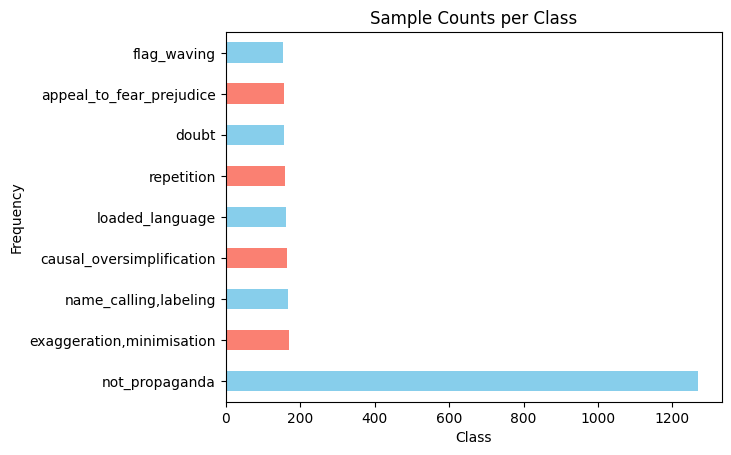

In [96]:
import matplotlib.pyplot as plt

counts = train_df['label'].value_counts()

# Pass the unique labels (index) and the counts (values)

counts.plot(kind='barh', color=['skyblue', 'salmon'])

plt.title("Sample Counts per Class")
plt.xlabel("Class")
plt.ylabel("Frequency")
plt.show()

#### b) What is the average length of sentence for each class?

In [97]:
train_df['context_length'] = train_df['tagged_in_context'].apply(lambda x: len(x.split())-2)

stats_per_class = train_df.groupby('label')['context_length'].agg(
    Count='count',
    Average='mean', 
    Minimum='min', 
    Maximum='max',
    Std='std',
    Var='var',
)

stats_per_class


,Count,Average,Minimum,Maximum,Std,Var
label,,,,,,
appeal_to_fear_prejudice,157,29.171975,4,79,14.793527,218.848440
causal_oversimplification,165,32.896970,4,119,19.547199,382.092979
doubt,157,31.012739,2,141,22.035515,485.563939
"exaggeration,minimisation",170,30.705882,3,73,16.823711,283.037243
flag_waving,155,30.251613,5,101,17.472648,305.293423
loaded_language,161,27.465839,1,80,16.472716,271.350388
"name_calling,labeling",166,33.078313,3,111,19.200376,368.654436
not_propaganda,1269,20.874704,1,100,13.212921,174.581292
repetition,160,24.262500,1,104,15.935991,253.955818


#### c) What is the average length of propaganda snippet for each class? 

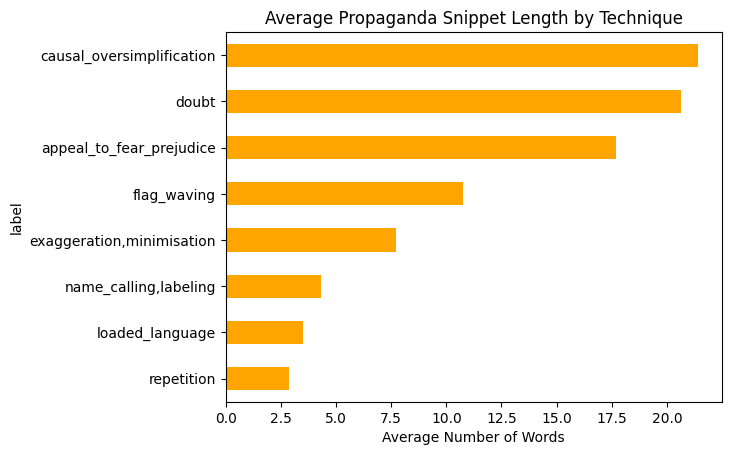

In [98]:
import re

def get_snippet_length(text):
    found = re.search(r'<BOS>(.*?)<EOS>', text)
    if found:
        snippet = found.group(1)
        return len(snippet.split())
    return 0

train_df['snippet_length'] = train_df['tagged_in_context'].apply(get_snippet_length)

propaganda_only = train_df[train_df['label'] != 'not_propaganda']

snippet_stats = propaganda_only.groupby('label')['snippet_length'].agg(['mean', 'min', 'max'])
snippet_stats


# 5. Visualize
snippet_stats['mean'].sort_values().plot(kind='barh', color='orange')
plt.title('Average Propaganda Snippet Length by Technique')
plt.xlabel('Average Number of Words')
plt.show()

### Exercise 2: Sentence Level Binary classification

Build a simple classifier (e.g., Naïve Bayes or Logistic Regression) which can take a sentence and predict whether it contains propaganda or not.  Things you will need to think about

* making a binary "propaganda" or "not_propaganda" label
* splitting the data into training and validation
* making a bag-of-words representation of each sentence.  This could be a dictionary where the keys are the words and the values are the frequencies within the sentence.  
* the implementation of the classifier itself.  You are not expected to build this yourself.  A good one to use would be the multinomialNB classifier in scikit-learn

It's worth thinking about the input format expected by the classifier before pre-processing the data.  Code to import and use the scikit-learn multinomialNB classifier is below for consideration

#### Toy Model

In [36]:
#This gives us some random toy data.  
#In this toy data there are 10 data points (e.g., sentences) 
# each sentence is represented as a vector of 100 values
# each value could be the frequency of a particular word in the vocab.  The max frequency here is 6
# these are stored in X
# there are 2 possible labels (0 and 1) which are stored in Y

import numpy as np
rng=np.random.RandomState()
X = rng.randint(6,size=(10,100))
Y = rng.randint(2, size=10)

print(X)
print(Y)

[[3 2 0 4 1 1 3 3 1 4 0 0 2 0 2 0 0 5 2 1 0 2 3 2 5 2 1 3 4 4 5 3 3 3 4 0
  2 1 0 5 1 0 5 1 2 5 1 5 5 1 5 3 2 2 5 1 2 5 0 2 1 5 0 0 1 3 3 1 3 2 1 1
  0 3 0 2 1 2 1 4 3 0 3 0 5 1 2 5 4 5 3 5 4 1 5 1 3 0 1 2]
 [1 4 1 1 0 4 3 2 0 1 1 1 2 3 1 1 4 1 0 0 0 0 4 5 2 3 0 4 3 1 0 0 4 0 5 0
  5 4 0 5 2 1 1 3 4 0 1 5 3 1 5 2 0 3 0 0 2 3 3 5 3 1 3 0 3 1 1 5 4 3 0 1
  2 4 3 4 1 3 5 3 0 3 3 5 2 1 3 2 1 3 1 3 4 0 5 5 5 4 4 1]
 [0 4 5 0 1 3 4 5 5 4 1 1 4 5 5 4 4 4 3 3 0 2 1 2 3 4 3 0 1 4 4 3 2 0 1 4
  2 4 1 3 0 4 3 3 4 1 4 2 4 3 3 0 3 0 5 5 0 2 5 3 5 4 1 4 3 2 1 4 0 2 5 4
  4 1 3 2 5 0 0 2 0 5 0 1 4 1 0 5 2 3 2 3 1 4 4 5 2 4 2 0]
 [3 1 0 3 5 5 3 4 1 4 1 4 0 0 1 3 1 3 2 2 0 1 2 4 4 4 4 2 2 5 3 0 5 3 5 5
  4 0 4 4 5 5 4 1 5 1 1 3 4 0 1 1 4 3 3 3 3 3 5 2 3 5 4 3 0 1 0 2 4 0 3 0
  2 2 1 2 5 1 4 5 1 5 4 0 2 1 3 4 4 2 3 3 1 2 3 4 5 0 4 2]
 [5 1 3 1 3 5 3 5 1 2 2 1 3 5 0 4 4 3 4 0 2 0 4 3 3 0 5 5 4 4 4 2 4 4 4 5
  2 3 1 0 2 0 2 3 1 1 2 5 0 0 0 4 2 4 3 3 3 2 1 1 5 5 0 2 4 0 2 3 1 5 5 5
  5 0 3 0 1 1 5 0 0 4 1 

In [37]:
import sklearn

#we can give this as input to the MultinomialNB classifier using the fit method
from sklearn.naive_bayes import MultinomialNB

classifier=MultinomialNB()
classifier.fit(X,Y)


,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [38]:
#we can predict the value for any datapoint
#here we are making up some more random points with random labels so I wouldn't expect particularly high accuracy!

X = rng.randint(6,size=(5,100))
Y = rng.randint(2, size=5)
print(Y)
classifier.predict(X)


[1 0 1 0 0]


array([1, 1, 1, 1, 1])

So imagine you have sentence representations and labels as follows.  We need to generate vectors for them where each column corresponds to a particular word in the vocabulary

In [39]:
toy_training_data=[({"everyone":1,"hates":1,"vectors":1},1),({"vectors":1,"are":1,"useful":1},0)]
Xdicts,Y=zip(*toy_training_data)


In [40]:
Xdicts

({'everyone': 1, 'hates': 1, 'vectors': 1},
 {'vectors': 1, 'are': 1, 'useful': 1})

In [41]:
Y

(1, 0)

We could write some code to turn the Xdicts into vectors (you first need to work out what the vocab is and assign an index to each vocab item).  Or we can use scikit-learn's `CountVectorizer` directly on the texts.

In [42]:
toy_training_data=[("everyone hates vectors",1),("vectors are useful",0)]
Xsents,Y=zip(*toy_training_data)
Xsents

('everyone hates vectors', 'vectors are useful')

In [43]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer=CountVectorizer()
vectorizer.fit(Xsents)

# Printing the identified Unique words along with their indices
print("Vocabulary: ", vectorizer.vocabulary_)
 
# Encode the sents
Xvectors = vectorizer.transform(Xsents)
 
print(Xvectors)

Vocabulary:  {'everyone': 1, 'hates': 2, 'vectors': 4, 'are': 0, 'useful': 3}
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 6 stored elements and shape (2, 5)>
  Coords	Values
  (0, 1)	1
  (0, 2)	1
  (0, 4)	1
  (1, 0)	1
  (1, 3)	1
  (1, 4)	1


In [44]:
classifier=MultinomialNB()
classifier.fit(Xvectors,Y)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [45]:
classifier.predict(Xvectors[1])

array([0])

What happens if some new sentences have words not in the vocabulary?  We can see here that they are just ignored by the vectorization process - this is fine as they are not going to help the classifier as they are unknown

In [46]:
toy_test_data=[("everyone hates useful vectors",1),("vectors are really useful",0)]
Xsents,Y=zip(*toy_test_data)
testVectors=vectorizer.transform(Xsents)

print(testVectors)


<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 7 stored elements and shape (2, 5)>
  Coords	Values
  (0, 1)	1
  (0, 2)	1
  (0, 3)	1
  (0, 4)	1
  (1, 0)	1
  (1, 3)	1
  (1, 4)	1


In [47]:
classifier.predict(testVectors)

array([1, 0])

---

#### Sentence Level Naive Bayes Classifier

Lets go back to a modified version of the exercise which assumes we are going to use CountVectorizer and MultinomialNB

Build a MultinomialNB classifier which can take a sentence and predict whether it contains propaganda or not.  Things you will need to think about

* making a binary "propaganda" or "not_propaganda" label
* splitting the data into training and validation
* making a bag-of-words representation of each sentence using CountVectorizer
* Training a MultinomialNB classifier on the training data and evaluating it on the validation data

In [99]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

# 1. Create the binary label
# We map 'not_propaganda' to 0 and everything else to 1
train_df['binary_label'] = train_df['label'].apply(lambda x: 0 if x == 'not_propaganda' else 1)
train_df.head(5)

,label,tagged_in_context,context_length,snippet_length,binary_label
0,not_propaganda,"No, <BOS> he <EOS> will not be confirmed.",6,1,0
1,not_propaganda,This declassification effort <BOS> won’t make ...,14,11,0
2,flag_waving,"""The Obama administration misled the <BOS> Ame...",21,2,1
3,not_propaganda,“It looks like we’re capturing the demise of t...,34,1,0
4,not_propaganda,"<BOS> Location: Westerville, Ohio <EOS>",3,3,0


In [100]:
# 2. Split the data into Training and Validation sets
# We use 'sentence' as our input feature (X) and 'binary_label' as our target (y)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    train_df['tagged_in_context'], 
    train_df['binary_label'], 
    test_size=0.2, 
    random_state=42
)

In [101]:
# 3. Create Bag-of-Words representation
vectorizer = CountVectorizer()

# Learn vocabulary and transform training data
X_train = vectorizer.fit_transform(X_train_raw)

# Transform validation data using the SAME vocabulary
X_val = vectorizer.transform(X_val_raw)

In [102]:
# 4. Train the MultinomialNB classifier
clf = MultinomialNB()
clf.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [103]:
# 5. Evaluate the model
predictions = clf.predict(X_val)
print("Binary Propaganda Classifier Performance:")
print(classification_report(y_val, predictions, target_names=['not_propaganda', 'propaganda']))

Binary Propaganda Classifier Performance:
                precision    recall  f1-score   support

not_propaganda       0.76      0.56      0.64       265
    propaganda       0.63      0.81      0.71       247

      accuracy                           0.68       512
     macro avg       0.69      0.68      0.67       512
  weighted avg       0.69      0.68      0.67       512



**For the propaganda class:** There is a large disparity between the precision (0.63) and the recall (0.81). The high Recall means that the model is very good at finding the postive examples in the test set. The **lower** Precision means that the model is overly keen to predict positive resulting in a larger cohort of False Positives. The model might be suggesting that normal words and phrases are "loaded" and therefore thinks they are propaganda.

**For the Neutral, Non-Propaganda Class:** There trend is the opposite, the Precision (0.76) is higher than the recall (0.56). The low recall means that 44% of the time the model thinks neutral inputs are propaganda. The Precision means that when it is condfident to prescribe a non-propaganda label, it is often correct. 

**F-1 Scores:** The F-1 Score for propaganda is larger (0.71) than the neutral class (0.64), meaning the model is better at handling the propaganda class. This is unusual for many NLP tasks where the "neutral" class is usually easier, but it suggests that the propaganda in this dataset has very distinct "Bag-of-Words" signatures (specific vocabulary) that the NB classifier can easily latch onto.

**Macro Average F1 (0.67):** This is the most important metric for your Lab 6 report. Since your classes are nearly balanced (265 vs 247 support), the macro average gives a fair view of the model's overall "intelligence" across both categories. A score of 0.67 is a respectable baseline for a simple word-count model.

---

**Key Analysis:**
Ultimately, what we can infer from this analysis is that the model is pretty good at finding propaganda. However, it is doing so in a way that makes it reckless and overconfient, often suggesting something is propaganda when it isn't (low precision). Remember, that our approach here is a BoW which no inference on word order. Therefore, we can safely assume that the model is latching on too heavily to the use of certain words. This makes sense as Propaganda is naunced, it requires the context of the rest of the sentence in order, and normally requires additionally external information to understand why something is propaganda due to the person saying it in the context which it has been said. 

> **Over-fitting to "Trigger Words":** The model has likely learned that certain words (e.g., "enemy," "traitor," "freedom") are 100% propaganda, even if they appear in a standard news report.

### Exercise 3: Snippet level binary classification

Repeat exercise 2 but train and test on propaganda snippets rather than whole sentences.

**How is this different:** Instead of taking the whole context sequences, we are extracting just the text between the tags. The model will only see the concetrated propaganda features. One interpretation of these could be that we are removing the "noise" which is the connective tissue of the sequence. 

#### Snippet Level Classifer

In [104]:
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

In [105]:
# 1. Extract the snippets for training
# We isolate the text between <BOS> and <EOS> tags. 
# For neutral samples, we use the whole sentence as the baseline "snippet".
def extract_snippet_text(row):
    # Regex to find text between the tags
    found = re.search(r'<BOS>(.*?)<EOS>', row['tagged_in_context'])
    if found:
        return found.group(1)
    return row['tagged_in_context']

# Apply the function to create our new feature column
train_df['snippet'] = train_df.apply(extract_snippet_text, axis=1)
train_df.head(5)

,label,tagged_in_context,context_length,snippet_length,binary_label,snippet
0,not_propaganda,"No, <BOS> he <EOS> will not be confirmed.",6,1,0,he
1,not_propaganda,This declassification effort <BOS> won’t make ...,14,11,0,won’t make things any worse than they are for...
2,flag_waving,"""The Obama administration misled the <BOS> Ame...",21,2,1,American people
3,not_propaganda,“It looks like we’re capturing the demise of t...,34,1,0,and
4,not_propaganda,"<BOS> Location: Westerville, Ohio <EOS>",3,3,0,"Location: Westerville, Ohio"


In [106]:
# 2. Prepare the binary labels (0 for neutral, 1 for propaganda)
train_df['binary_label'] = train_df['label'].apply(lambda x: 0 if x == 'not_propaganda' else 1)
train_df.head(5)

,label,tagged_in_context,context_length,snippet_length,binary_label,snippet
0,not_propaganda,"No, <BOS> he <EOS> will not be confirmed.",6,1,0,he
1,not_propaganda,This declassification effort <BOS> won’t make ...,14,11,0,won’t make things any worse than they are for...
2,flag_waving,"""The Obama administration misled the <BOS> Ame...",21,2,1,American people
3,not_propaganda,“It looks like we’re capturing the demise of t...,34,1,0,and
4,not_propaganda,"<BOS> Location: Westerville, Ohio <EOS>",3,3,0,"Location: Westerville, Ohio"


In [134]:
# 3. Split the data
# NOTE: We are now using 'snippet' as our X input
X_train_raw_snippet, X_val_raw_snippet, y_train_snippet, y_val_snippet = train_test_split(
    train_df['snippet'], 
    train_df['binary_label'], 
    test_size=0.2, 
    random_state=42
)

In [128]:
X_val_raw_snippet

2156                   incompetent, clueless authorities 
1737                                   Farrakhan quotes: 
1173                                                trip 
478                   mayor of San Francisco but lost to 
1356                                              State. 
                              ...                        
1242                                   Keep in mind that 
856                       What are these people smoking? 
1667     The Federation Council, the Religious Assista...
2467                    that are indefatigably committed 
1463                                           in prison 
Name: snippet, Length: 512, dtype: str

In [108]:
# 4. Feature Extraction (Bag-of-Words)
vectorizer_snippet = CountVectorizer()
X_train_snippet = vectorizer_snippet.fit_transform(X_train_raw_snippet)
X_val_snippet = vectorizer_snippet.transform(X_val_raw_snippet)

In [109]:
# 5. Train the MultinomialNB Classifier
clf_snippet = MultinomialNB()
clf_snippet.fit(X_train_snippet, y_train_snippet)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [110]:
# 6. Evaluate the results
predictions_snippet = clf_snippet.predict(X_val_snippet)
print("Snippet-Level Binary Classification Performance:")
print(classification_report(y_val_snippet, predictions_snippet, target_names=['not_propaganda', 'propaganda']))

Snippet-Level Binary Classification Performance:
                precision    recall  f1-score   support

not_propaganda       0.74      0.39      0.51       265
    propaganda       0.56      0.85      0.68       247

      accuracy                           0.61       512
     macro avg       0.65      0.62      0.59       512
  weighted avg       0.65      0.61      0.59       512



In this model the Propaganda Recall rose to 0.85 while Non-Propaganda Recall plummeted to 0.39. This has just increased the issues that the model already had. It is even more likely to predict neutral text and prop and appears to find even more of the True Positive. 

A recall of 0.39 for the majority/neutral class is very poor for a baseline. It means that 61% of neutral statements are being falsely accused of being propaganda.

The model has completely lost the ability to predict a neutral sentence. It is starting to begin to think regular features within the BoW make it propaganda. 

**Degradation of Discriminative Power:** The drop in Macro F1 (from 0.67 to 0.59) proves that the model is performing worse overall. Even though it "finds" more propaganda, its inability to distinguish it from neutral text makes the model less useful than the sentence-level version.

> The F1-score is a single metric that balances two competing priorities in classification: Precision (how many of the predicted positives were correct) and Recall (how many of the actual positives were caught). It is calculated as the harmonic mean of these two values, which is more effective than a simple average because it penalizes models that "cheat" by only scoring well in one area. For example, a model that predicts everything as "propaganda" might have perfect recall but terrible precision; the F1-score would reflect this failure by dropping significantly.
> 
> $$F_1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

### Exercise 4: Mixing snippets and sentence

* How well does your sentence level classifier work on snippets?  
* How well does snippet level classifier work on sentences?
* What about if you train on both sentences and snippets?

**Cross-Domain Evaluation**. This exercise tests the **robustness** and **generalizability** of your models by asking them to predict on data formats they weren't specifically trained on, e.g. take the model from Exercise 2 (trained on full sentences) and ask it to classify the isolated snippets from Exercise 3.

**The Goal:** To see if the model has learned the specific "propaganda keywords" or if it relies too heavily on the surrounding sentence structure.

#### Sentence Level Classifer on Snippets

In [131]:
# Transform snippets using the SENTENCE vectorizer
X_val_snip_for_sent_model = vectorizer.transform(X_val_raw_snippet) 

# Predict using the SENTENCE classifier
sent_on_snip_preds = clf.predict(X_val_snip_for_sent_model)

print("Sentence-level model tested on Snippets:")
print(classification_report(y_val_snippet, sent_on_snip_preds))

Sentence-level model tested on Snippets:
              precision    recall  f1-score   support

           0       0.75      0.44      0.56       265
           1       0.58      0.84      0.69       247

    accuracy                           0.63       512
   macro avg       0.67      0.64      0.62       512
weighted avg       0.67      0.63      0.62       512



#### Snippet Level Classifer on Sentences

In [132]:
# Transform full sentences using the SNIPPET vectorizer
X_val_sent_for_snip_model = vectorizer_snippet.transform(X_val_raw) 

# Predict using the SNIPPET classifier
snip_on_sent_preds = clf_snippet.predict(X_val_sent_for_snip_model)

print("Snippet-level model tested on Sentences:")
print(classification_report(y_val, snip_on_sent_preds))

Snippet-level model tested on Sentences:
              precision    recall  f1-score   support

           0       0.75      0.46      0.57       265
           1       0.59      0.83      0.69       247

    accuracy                           0.64       512
   macro avg       0.67      0.65      0.63       512
weighted avg       0.67      0.64      0.63       512



**Sentence-model on Snippets:** When you give a snippet to the sentence model, you are essentially giving it a sentence with all the "neutral" words removed. Since the model already largely ignored those neutral words to focus on propaganda "trigger words," its performance remains nearly the same.

**Snippet-model on Sentences:** Conversely, when you give a full sentence to the snippet model, you are adding neutral "noise" around the propaganda. Since MultinomialNB is mathematically robust to features (words) that have low probability across all classes, it simply "filters out" the neutral context and finds the same propaganda words it was trained on.

Note, that both models have low recall on the non-propaganda. This means that the model simply is not learning the neutral class. It thinks that if it sees a 'loaded' word it is propagranda. This is highlighting an issue with the underlying BoW approach. 

The fact that the F1-scores are nearly identical (0.69) shows that for a Bag-of-Words model, the scale of the text doesn't matter. Whether the "signal" is isolated or buried in context, the model's ability to discriminate between the two remains exactly the same.

---

#### Mixing the Training Data

The results of the previous two cross models were largely uninteresting and continued to face the same bias. However, by combining the data, we can potentially increase the diversity and scope of the trianing data - or just reinforce the bais even further. 

This is a technique called Data Augmentation. This involves combining the full-sentence training data with the isolated snippet training data to create a larger, more diverse dataset.

In [136]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

# 1. Combine the training features (X)
# We take the sentences and snippets we extracted earlier
X_mixed_raw = pd.concat([X_train_raw, X_train_raw_snippet])

# 2. Duplicate the training labels (y) 
# Since we doubled the text data, we must double the labels to match
y_mixed = pd.concat([y_train, y_train_snippet])

# 3. Fit the Vectorizer on the new combined dataset
vectorizer_mixed = CountVectorizer()
X_mixed_train = vectorizer_mixed.fit_transform(X_mixed_raw)

# 4. Train the Mixed Classifier
clf_mixed = MultinomialNB()
clf_mixed.fit(X_mixed_train, y_mixed)

# 5. Evaluate on both Sentence and Snippet Validation Sets
# This allows you to see if the mixed model is a better "all-rounder"
X_val_sent = vectorizer_mixed.transform(X_val_raw) # sentences
X_val_snip = vectorizer_mixed.transform(X_val_raw_snippet) # snippets

print("Mixed Model evaluated on Sentences:")
print(classification_report(y_val, clf_mixed.predict(X_val_sent)))

print("Mixed Model evaluated on Snippets:")
print(classification_report(y_val, clf_mixed.predict(X_val_snip)))

Mixed Model evaluated on Sentences:
              precision    recall  f1-score   support

           0       0.73      0.61      0.67       265
           1       0.65      0.76      0.70       247

    accuracy                           0.68       512
   macro avg       0.69      0.69      0.68       512
weighted avg       0.69      0.68      0.68       512

Mixed Model evaluated on Snippets:
              precision    recall  f1-score   support

           0       0.76      0.46      0.58       265
           1       0.60      0.85      0.70       247

    accuracy                           0.65       512
   macro avg       0.68      0.66      0.64       512
weighted avg       0.68      0.65      0.64       512



The macro-f1 has increased for both sentences and snippets. In fact, snippets increased from 0.59 to 0.64. 

The main issue of the models has been its trigger happiness. However, we can see that the augmentation has begun to mend this as recall for the Sentence model has improved from 0.56 to 0.61 and the Snippets 0.39 to 0.46. Both are still low but it shows the model become less senstive to loaded words. 

This dual-exposure reduces the model's tendency to false-flag neutral text while maintaining high sensitivity to actual propaganda.

### Extensions

#### 1.) Can you use cross-validation to evaluate your classifiers rather than a single training/development split

**What it means:** Instead of splitting your data once (e.g., 80% train, 20% test), you divide the data into $k$ equal parts (folds). You train the model $k$ times, each time using a different fold as the test set and the remaining folds as training data.

**Why it’s important:** A single split can be "lucky" or "unlucky" depending on which specific sentences end up in the test set. Cross-validation provides a more stable and reliable estimate of how your model will perform on completely unseen data.

---

#### 2.) Can you use a different type of classifier and / or feature representation.  E.g., logistic regression where the feature values are tf-idf values rather than frequencies?

**What it means:** This suggests replacing the simple word counts from CountVectorizer with TF-IDF (Term Frequency-Inverse Document Frequency). TF-IDF "punishes" words that appear in almost every document (like "the" or "said") and "rewards" words that are unique to specific documents.


**Why it’s important:** In propaganda detection, common words are noise. TF-IDF helps the model focus on the "loaded" or specialized vocabulary that characterizes propaganda. Switching classifiers (e.g., to Logistic Regression) can also help, as some models handle the "relationships" between features better than Naive Bayes.


---

#### 3.) Can you carry out multi-class classification to identify the propaganda technique used?


**What it means:** Currently, your model only does "binary" classification (Is it propaganda?). This extension asks you to identify which of the 14 specific techniques (e.g., Slogans, Loaded Language, Flag-Waving) is being used.

**Why it’s important:** Identifying that something is propaganda is useful, but identifying how it is trying to manipulate you is much more powerful for media literacy and automated fact-checking. This is a significantly harder task because some classes have very few examples.

---

#### 4.) Does it help to first use your binary classifier to decide whether there is any propaganda or not?

**What it means:** This asks if it is better to have one big model that tries to do everything, or a pipeline:
1. **Model A:** A binary classifier that acts as a "filter" to decide if a sentence is propaganda.
2. **Model B:** If Model A says "Yes," pass the text to a specialized multi-class model to name the technique.

**Why it’s important:** This "Divide and Conquer" approach often works better in NLP. It allows the first model to become an expert at finding propaganda in general, while the second model can focus entirely on the subtle differences between specific techniques without getting distracted by millions of neutral sentences.

---